core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '63', '44', '81', '14', '18', '3', '10', '31', '27', '20', '77', '22', '24', '55', '23', '11', '16', '2']
C:\Users\tudor\anaconda3\Lib\site-packages\fastf1\core.py:312

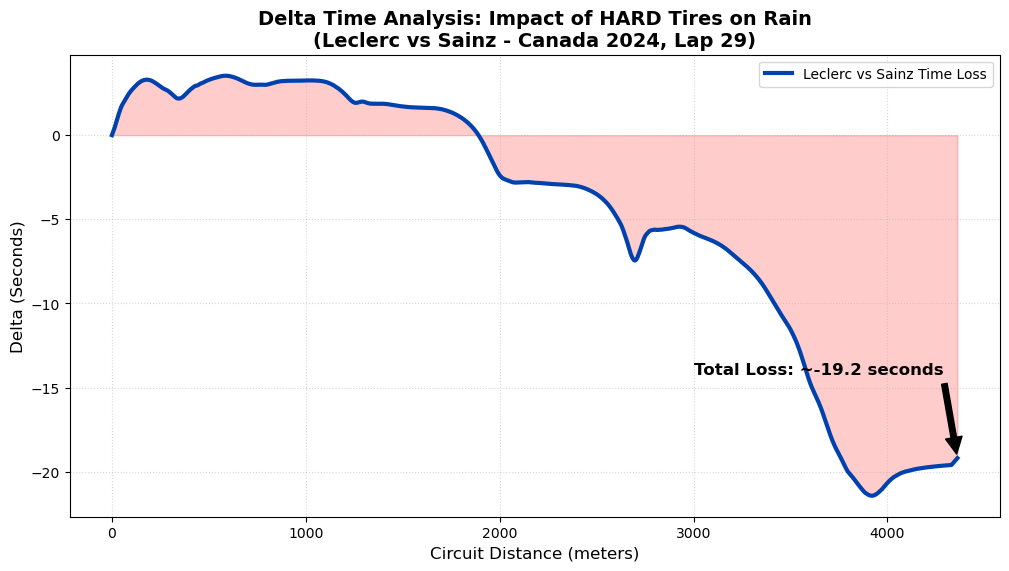

In [3]:
import fastf1
import matplotlib.pyplot as plt
import numpy as np

session = fastf1.get_session(2024, 'Canada', 'R')
session.load()

lec_lap = session.laps.pick_driver('LEC').iloc[28].get_telemetry().add_distance()
sai_lap = session.laps.pick_driver('SAI').iloc[28].get_telemetry().add_distance()

dist_common = np.linspace(0, 4361, 1000)

time_lec = np.interp(dist_common, lec_lap['Distance'], lec_lap['Time'].dt.total_seconds())
time_sai = np.interp(dist_common, sai_lap['Distance'], sai_lap['Time'].dt.total_seconds())

time_lec -= time_lec[0]
time_sai -= time_sai[0]

delta_time = time_lec - time_sai

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

ax.plot(dist_common, delta_time, color='#0042AD', linewidth=3, label='Leclerc vs Sainz Time Loss')
ax.fill_between(dist_common, delta_time, color='red', alpha=0.2)

ax.set_title("Delta Time Analysis: Impact of HARD Tires on Rain\n(Leclerc vs Sainz - Canada 2024, Lap 29)", 
             fontsize=14, fontweight='bold')
ax.set_xlabel("Circuit Distance (meters)", fontsize=12)
ax.set_ylabel("Delta (Seconds)", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend()

max_delta = delta_time[-1]
ax.annotate(f'Total Loss: ~{max_delta:.1f} seconds', 
            xy=(4361, max_delta), xytext=(3000, max_delta + 5),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=12, fontweight='bold')

plt.show()

C:\Users\tudor\anaconda3\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\tudor\anaconda3\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


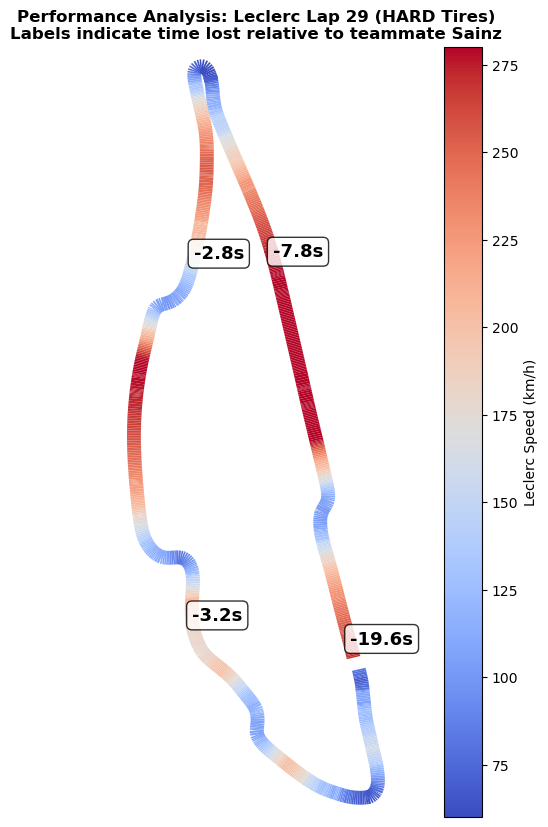

In [2]:
import fastf1
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

lec_lap = session.laps.pick_driver('LEC').iloc[28].get_telemetry().add_distance()
sai_lap = session.laps.pick_driver('SAI').iloc[28].get_telemetry().add_distance()

dist_common = np.linspace(0, 4361, 1000)
speed_lec = np.interp(dist_common, lec_lap['Distance'], lec_lap['Speed'])
time_lec = np.interp(dist_common, lec_lap['Distance'], lec_lap['Time'].dt.total_seconds())
time_sai = np.interp(dist_common, sai_lap['Distance'], sai_lap['Time'].dt.total_seconds())

time_lec -= time_lec[0]
time_sai -= time_sai[0]
delta_time = time_lec - time_sai

x = np.interp(dist_common, lec_lap['Distance'], lec_lap['X'])
y = np.interp(dist_common, lec_lap['Distance'], lec_lap['Y'])

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

fig, ax = plt.subplots(figsize=(12, 10), facecolor='white')

norm = plt.Normalize(vmin=60, vmax=280)
lc = LineCollection(segments, cmap='coolwarm', norm=norm, linewidth=10)
lc.set_array(speed_lec)
line = ax.add_collection(lc)

indices = [250, 500, 750, 990]
for i in indices:
    ax.text(x[i], y[i], f"-{abs(delta_time[i]):.1f}s", color='black',
            fontsize=13, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.8))

ax.set_xlim(x.min() - 500, x.max() + 500)
ax.set_ylim(y.min() - 500, y.max() + 500)
ax.set_aspect('equal')
ax.axis('off')

cb = fig.colorbar(line, ax=ax)
cb.set_label('Leclerc Speed (km/h)')

plt.title("Performance Analysis: Leclerc Lap 29 (HARD Tires)\nLabels indicate time lost relative to teammate Sainz", fontweight='bold')
plt.show()